In [1]:
import time
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import DensityMatrix, Operator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

In [2]:
def outer(psi):
    v = psi.reshape(-1, 1); return v @ v.conj().T

def trdist(rho, sigma):
    return np.sum(np.abs(np.linalg.svdvals(rho - sigma))) / 2

def sample_gcauchy(beta, M=1):
    thresh = (1 + np.sqrt(5)) / 2; out = []
    while len(out) < M:
        c = scipy.stats.cauchy.rvs(); u = scipy.stats.uniform.rvs()
        if u < (1 + c**2) / (1 + (c / np.sqrt(2)) ** 4) / thresh: out.append(c)
    return beta * (np.array(out) if M > 1 else out[0])

def ite_pauli_gadget(qc, anc, cbit, pauli, gamma_dtau, *, data_qubits=None):
    pauli = ''.join(pauli) if isinstance(pauli, (list, tuple)) else pauli
    n = len(pauli); data_qubits = list(range(n)) if data_qubits is None else data_qubits
    supp = [i for i, p in enumerate(pauli) if p != 'I']
    if not supp or gamma_dtau == 0: return qc
    for i in supp:
        q = data_qubits[i]
        if pauli[i] == 'X': qc.h(q)
        elif pauli[i] == 'Y': qc.sdg(q); qc.h(q)
    chain = [data_qubits[i] for i in supp]
    for a, b in zip(chain[:-1], chain[1:]): qc.cx(a, b)
    parity_q = chain[-1]
    if gamma_dtau > 0: qc.x(parity_q)
    phi = 2 * np.arccos(np.exp(-2 * abs(gamma_dtau)))
    qc.crx(phi, parity_q, anc); qc.measure(anc, cbit); qc.reset(anc)
    if gamma_dtau > 0: qc.x(parity_q)
    for a, b in zip(chain[-2::-1], chain[-1:0:-1]): qc.cx(a, b)
    for i in reversed(supp):
        q = data_qubits[i]
        if pauli[i] == 'X': qc.h(q)
        elif pauli[i] == 'Y': qc.h(q); qc.s(q)
    return qc

def rte_pauli_gadget(qc, P, theta, qubits=None):
    n = len(P); qubits = list(range(n)) if qubits is None else qubits
    supp = [i for i, p in enumerate(P) if p != 'I']
    if not supp: return qc
    for i in supp:
        q = qubits[i]
        if P[i] == 'X': qc.h(q)
        elif P[i] == 'Y': qc.sdg(q); qc.h(q)
    chain = [qubits[i] for i in supp]
    for a, b in zip(chain[:-1], chain[1:]): qc.cx(a, b)
    qc.rz(2 * theta, chain[-1])
    for a, b in zip(chain[-2::-1], chain[-1:0:-1]): qc.cx(a, b)
    for i in reversed(supp):
        q = qubits[i]
        if P[i] == 'X': qc.h(q)
        elif P[i] == 'Y': qc.h(q); qc.s(q)
    return qc

def trotter_pauli(terms, alpha, *, steps=1, order=2):
    norm = [(t, 1.0) if isinstance(t, str) else (t[0], float(t[1])) for t in terms]
    def S(x, o):
        if o == 1: return [(P, x * w) for P, w in norm]
        if o == 2:
            fwd = [(P, (x / 2) * w) for P, w in norm]
            return fwd + list(reversed(fwd))
        p = 1 / (4 - 4 ** (1 / (o - 1)))
        return S(p * x, o - 2) + S((1 - 2 * p) * x, o - 2) + S(p * x, o - 2)
    return S(alpha / steps, order) * steps

def spin_chain_H_terms(n, J=1.0, g=1.0):
    Hs = []
    for i in range(n - 1):
        p = list('I' * n); p[i] = p[i + 1] = 'Z'; Hs.append((''.join(p), -J))
    for i in range(n):
        p = list('I' * n); p[i] = 'X'; Hs.append((''.join(p), -J * g))
    return Hs

def H_to_matrix(Hs):
    n = len(Hs[0][0]); Hm = np.zeros((2**n, 2**n), dtype=complex)
    for t in Hs:
        P, w = (t, 1.0) if isinstance(t, str) else (t[0], float(t[1]))
        Hm += w * Operator.from_label(''.join(P[::-1])).data
    return Hm

def make_noise_model(p):
    if not p: return None
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p, 1), ['x', 'h', 's', 'sdg', 'rz', 'rx'])
    nm.add_all_qubit_quantum_error(depolarizing_error(p, 2), ['cx', 'crx'])
    return nm

def _is_zero_key(k):
    s = str(k).replace(' ', '')
    return int(s, 16) == 0 if s.startswith('0x') else (bool(s) and set(s) <= {'0'})

def _extract_zero_branch_dm(res, tqc, label='rho', atol=1e-14):
    by_key = res.data(tqc)[label]
    ks = [k for k in by_key if _is_zero_key(k)]
    if not ks: return None, 0.0
    rho = np.asarray(getattr(by_key[ks[0]], 'data', by_key[ks[0]]), dtype=complex)
    w = float(np.real(np.trace(rho)))
    return (None, 0.0) if w <= atol else (rho / w, w)

In [4]:
n = 4
g = 1.4
J = 1.0
betas = np.linspace(1e-3, 1.0, 10)
trotter = (10, 2)
rte_samples = 100
ite_shot_batch = 64
ite_max_shots = 2000
batch_size = 16
noise = 1e-4

Hs = spin_chain_H_terms(n, J=J, g=g)
Hmat = H_to_matrix(Hs)
w, V = np.linalg.eigh(Hmat)
ground_rho = outer(V[:, 0])

## Fix note

The checkpointed ITE path now carries the **full system+ancilla density matrix** between ITE gadgets. 
The previous version saved a reduced system density matrix after each gadget and then re-embedded it with a guessed tensor-product order; 
that can silently permute/reorder the density matrix before the next gadget. 
At the end, the appended ancilla is traced out explicitly using little-endian block indices.


In [6]:
def build_ite_circuit(Hs, n, beta, *, trotter, save_full=True):
    """Full ITE circuit used only as a reference check.

    The old notebook saved a reduced system density matrix inside each checkpoint
    and then fed that reduced matrix back into set_density_matrix. That is fragile:
    Qiskit's reduced-density-matrix data ordering is easy to mismatch with the
    ordering expected by set_density_matrix. The checkpointed path below instead
    saves the full (system + ancilla) density matrix and carries that full matrix
    forward. Only at the very end do we trace out the reset ancilla explicitly.
    """
    sched = trotter_pauli(Hs, beta, steps=trotter[0], order=trotter[1])
    main = QuantumRegister(n, 'q')
    anc = QuantumRegister(1, 'anc')
    creg = ClassicalRegister(len(sched), 'c')
    qc = QuantumCircuit(main, anc, creg)

    for i in range(n):
        qc.h(main[i])

    for j, (P, c) in enumerate(sched):
        ite_pauli_gadget(qc, anc[0], creg[j], P, gamma_dtau=c)

    if save_full:
        qc.save_density_matrix(label='rho_full', conditional=True, unnormalized=True)
    else:
        qc.save_density_matrix(qubits=list(range(n)), label='rho', conditional=True, unnormalized=True)
    return qc


def _zero_count_from_result(res, tqc):
    """Number of shots whose classical memory/count key is all zero."""
    try:
        counts = res.get_counts(tqc)
    except Exception:
        return None
    z = 0
    for key, val in counts.items():
        if _is_zero_key(key):
            z += int(val)
    return z


def _extract_zero_branch_dm(res, tqc, label='rho', atol=1e-14):
    """Extract normalized all-zero conditional density matrix from an Aer save.

    Returns (rho, weight, zero_count).  The 'weight' is the trace of the saved
    branch matrix. Depending on Aer version/save mode this may or may not be an
    actual probability, so use zero_count for sampling diagnostics.
    """
    by_key = res.data(tqc)[label]
    ks = [k for k in by_key if _is_zero_key(k)]
    if not ks:
        return None, 0.0, 0

    rho = np.asarray(getattr(by_key[ks[0]], 'data', by_key[ks[0]]), dtype=complex)
    w = float(np.real(np.trace(rho)))
    if w <= atol:
        return None, 0.0, 0

    zc = _zero_count_from_result(res, tqc)
    return rho / w, w, (0 if zc is None else zc)


def _embed_system_with_clean_ancilla(rho_sys):
    """Embed an n-qubit system density matrix with an appended ancilla |0><0|.

    Qiskit/Aer state indexing is little-endian: qubit 0 is the least significant
    bit. Since the ancilla register is appended after the n system qubits, it is
    qubit n, i.e. the most significant bit. Therefore the full matrix is block
    diagonal with the system density matrix in the ancilla=0 block:

        [[rho_sys, 0],
         [0,       0]].

    This is np.kron(|0><0|, rho_sys), not np.kron(rho_sys, |0><0|).
    """
    rho_sys = np.asarray(rho_sys, dtype=complex)
    anc0 = np.array([[1, 0], [0, 0]], dtype=complex)
    return np.kron(anc0, rho_sys)


def _trace_out_appended_ancilla(rho_full, n):
    """Trace out appended ancilla qubit n from an (n+1)-qubit density matrix.

    This avoids relying on Qiskit's reduced-density-matrix ordering when
    checkpointing. It returns the n-qubit system density matrix in the same
    little-endian basis used by H_to_matrix.
    """
    rho_full = np.asarray(rho_full, dtype=complex)
    D = 2**n
    if rho_full.shape != (2 * D, 2 * D):
        raise ValueError(f'Expected full density matrix shape {(2*D, 2*D)}, got {rho_full.shape}.')

    idx0 = np.arange(D)          # ancilla bit n = 0
    idx1 = idx0 + D              # ancilla bit n = 1
    rho_sys = rho_full[np.ix_(idx0, idx0)] + rho_full[np.ix_(idx1, idx1)]
    tr = np.trace(rho_sys)
    if abs(tr) > 0:
        rho_sys = rho_sys / tr
    return rho_sys


def _build_checkpoint_segment_from_full(rho_full, n, P, c):
    """One checkpoint segment: initialize full system+ancilla state, apply one ITE gadget."""
    main = QuantumRegister(n, 'q')
    anc = QuantumRegister(1, 'anc')
    creg = ClassicalRegister(1, 'c')
    qc = QuantumCircuit(main, anc, creg)

    # Full-width set_density_matrix avoids all reduced-density-matrix ordering issues.
    qc.set_density_matrix(DensityMatrix(np.asarray(rho_full, dtype=complex)))
    ite_pauli_gadget(qc, anc[0], creg[0], P, gamma_dtau=c)

    # Save the full density matrix so the next checkpoint can be initialized exactly.
    qc.save_density_matrix(label='rho_full', conditional=True, unnormalized=True)
    return qc


def run_ite_density_full(Hs, n, beta, *, shot_batch, max_shots, trotter, noise_model, pbar=None):
    """Reference full-circuit postselection; returns system density matrix."""
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    sim.set_options(max_parallel_threads=0, max_parallel_experiments=0, max_parallel_shots=0)
    tqc = transpile(build_ite_circuit(Hs, n, beta, trotter=trotter, save_full=True), sim)

    used = 0
    while used < max_shots:
        m = min(shot_batch, max_shots - used)
        res = sim.run(tqc, shots=m).result()
        rho_full, w, zc = _extract_zero_branch_dm(res, tqc, label='rho_full')
        used += m
        if pbar is not None:
            pbar.update(1)
        if rho_full is not None:
            return _trace_out_appended_ancilla(rho_full, n), w, used, zc

    D = 2**n
    return np.full((D, D), np.nan, dtype=complex), 0.0, used, 0


def run_ite_density_checkpointed(
    Hs, n, beta, *, shot_batch, max_shots_per_gadget, trotter, noise_model,
    pbar=None, verbose=False
):
    """Checkpointed ITE by conditioning on c=0 one gadget at a time.

    The crucial fix is that the checkpointed state is stored as the full
    (system+ancilla) density matrix. The old implementation saved only the
    reduced system density matrix after each gadget and re-embedded it with a
    guessed tensor order; that can feed the next step a permuted/wrong state.
    """
    sched = trotter_pauli(Hs, beta, steps=trotter[0], order=trotter[1])
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    sim.set_options(max_parallel_threads=0, max_parallel_experiments=0, max_parallel_shots=0)

    plus = np.ones(2**n, dtype=complex) / np.sqrt(2**n)
    rho_full = _embed_system_with_clean_ancilla(outer(plus))

    step_weights, step_tries, step_zero_counts = [], [], []

    for si, (P, c) in enumerate(sched):
        if verbose:
            print(f'gadget {si + 1}/{len(sched)}')

        used = 0
        done = False

        # Transpile once per gadget/current state. We must rebuild because set_density_matrix
        # contains numerical state data.
        tqc = transpile(_build_checkpoint_segment_from_full(rho_full, n, P, c), sim)

        while used < max_shots_per_gadget and not done:
            m = min(shot_batch, max_shots_per_gadget - used)
            res = sim.run(tqc, shots=m).result()
            rho_next_full, w, zc = _extract_zero_branch_dm(res, tqc, label='rho_full')
            used += m
            if pbar is not None:
                pbar.update(1)

            if rho_next_full is not None:
                rho_full = rho_next_full
                step_weights.append(w)
                step_tries.append(used)
                step_zero_counts.append(zc)
                done = True

        if not done:
            D = 2**n
            return np.full((D, D), np.nan, dtype=complex), 0.0, step_weights, step_tries, step_zero_counts

    rho_sys = _trace_out_appended_ancilla(rho_full, n)

    # This product is only a rough diagnostic; Aer's trace convention for
    # unnormalized conditional saves differs by version.
    p_all_diag = float(np.exp(np.sum(np.log(np.clip(step_weights, 1e-300, 1.0))))) if step_weights else 1.0
    return rho_sys, p_all_diag, step_weights, step_tries, step_zero_counts


def build_rte_circuit_from_rho(Hs, n, rho_in, t, *, trotter):
    qc = QuantumCircuit(n)
    qc.set_density_matrix(DensityMatrix(np.asarray(rho_in, dtype=complex)))
    for P, c in trotter_pauli(Hs, t, steps=trotter[0], order=trotter[1]):
        rte_pauli_gadget(qc, P, c)
    qc.save_density_matrix(label='rho_out')
    return qc


def run_rte_from_rho(Hs, n, beta, rho_ite, *, samples, trotter, noise_model, batch_size=16, pbar=None):
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    sim.set_options(max_parallel_threads=0, max_parallel_experiments=0, max_parallel_shots=1)
    out = []

    for s in range(0, samples, batch_size):
        m = min(batch_size, samples - s)
        circuits = [
            build_rte_circuit_from_rho(Hs, n, rho_ite, sample_gcauchy(beta), trotter=trotter)
            for _ in range(m)
        ]
        tqcs = transpile(circuits, sim)
        res = sim.run(tqcs, shots=1).result()
        out.extend(np.asarray(res.data(tqc)['rho_out'].data, dtype=complex) for tqc in tqcs)
        if pbar is not None:
            pbar.update(1)

    return sum(out) / len(out)


def run_split_over_betas(
    Hs, n, betas, *, trotter, rte_samples, ite_shot_batch, ite_max_shots,
    noise_model, batch_size=16, checkpointed=True
):
    D = 2**n
    B = len(betas)
    rho_ite = np.zeros((B, D, D), dtype=complex)
    rho_rite = np.zeros((B, D, D), dtype=complex)
    p_ite = np.zeros(B, dtype=float)
    meta = []

    n_rte_batches = (rte_samples + batch_size - 1) // batch_size

    for bi, beta in enumerate(tqdm(betas, desc='split sweep', unit='beta')):
        sched_len = len(trotter_pauli(Hs, beta, steps=trotter[0], order=trotter[1]))
        n_ite_batches = sched_len if checkpointed else (ite_max_shots + ite_shot_batch - 1) // ite_shot_batch

        with tqdm(total=n_ite_batches + n_rte_batches, desc=f'beta {bi + 1}/{B}', unit='batch', leave=False) as pbar_beta:
            if checkpointed:
                rho_i, p, step_ws, step_tries, step_zcs = run_ite_density_checkpointed(
                    Hs, n, beta,
                    shot_batch=ite_shot_batch,
                    max_shots_per_gadget=ite_max_shots,
                    trotter=trotter,
                    noise_model=noise_model,
                    pbar=pbar_beta,
                )
                meta.append({'weights': step_ws, 'tries': step_tries, 'zero_counts': step_zcs})
                avg_shots = float(np.mean(step_tries)) if step_tries else float('inf')
                print(f'beta {bi + 1}/{B} ITE(checkpoint): avg gadget shots={avg_shots:.1f}')
            else:
                rho_i, p, used, zc = run_ite_density_full(
                    Hs, n, beta,
                    shot_batch=ite_shot_batch,
                    max_shots=ite_max_shots,
                    trotter=trotter,
                    noise_model=noise_model,
                    pbar=pbar_beta,
                )
                meta.append({'used': used, 'zero_count': zc})
                print(f'beta {bi + 1}/{B} ITE(full): shots used={used}, zero_count={zc}')

            rho_ite[bi], p_ite[bi] = rho_i, p
            rho_rite[bi] = run_rte_from_rho(
                Hs, n, beta, rho_i,
                samples=rte_samples,
                trotter=trotter,
                noise_model=noise_model,
                batch_size=batch_size,
                pbar=pbar_beta,
            )

    return rho_ite, rho_rite, p_ite, meta


In [7]:
beta_bench = 0.25
nm = make_noise_model(noise)

st = time.perf_counter()
rho_full, p_full, used_full, zc_full = run_ite_density_full(
    Hs, n, beta_bench,
    shot_batch=ite_shot_batch,
    max_shots=ite_max_shots,
    trotter=trotter,
    noise_model=nm,
)
t_full = time.perf_counter() - st

st = time.perf_counter()
rho_chk, p_chk, step_ws, step_tries, step_zcs = run_ite_density_checkpointed(
    Hs, n, beta_bench,
    shot_batch=ite_shot_batch,
    max_shots_per_gadget=ite_max_shots,
    trotter=trotter,
    noise_model=nm,
)
t_chk = time.perf_counter() - st

print(f"beta={beta_bench:.3f}")
print(f"full-postselect   : {t_full:.2f}s, shots={used_full}, zero_count={zc_full}")
print(f"checkpointed      : {t_chk:.2f}s, mean gadget tries={np.mean(step_tries):.1f}")
print(f"speedup (full/chk): {t_full / max(t_chk, 1e-12):.2f}x")
print(f"||rho_full-rho_chk||_F = {np.linalg.norm(rho_full - rho_chk):.3e}")
print(f"trdist(full, ground) = {trdist(rho_full, ground_rho):.3e}")
print(f"trdist(chk,  ground) = {trdist(rho_chk, ground_rho):.3e}")


beta=0.250
full-postselect   : 0.64s, shots=64, zero_count=12
checkpointed      : 1.79s, mean gadget tries=64.0
speedup (full/chk): 0.36x
||rho_full-rho_chk||_F = 3.034e-03
trdist(full, ground) = 9.680e-02
trdist(chk,  ground) = 9.824e-02


checkpointed ITE-only:   0%|          | 0/10 [00:00<?, ?beta/s]

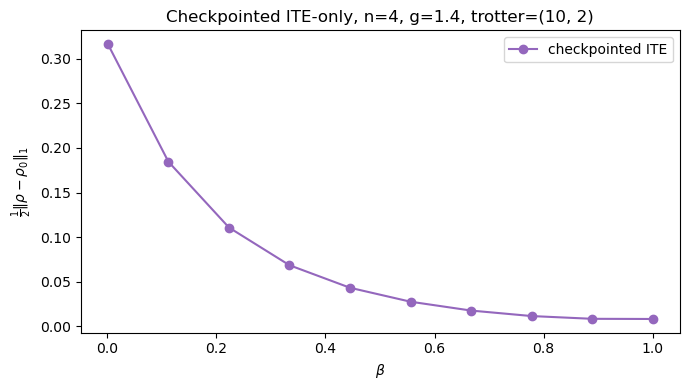

checkpointed ITE diagnostic p product per beta: ['1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00']
mean gadget shots per beta: [64. 64. 64. 64. 64. 64. 64. 64. 64. 64.]


In [8]:
# Checkpointed ITE-only beta sweep: trace distance to ground state
betas_ck = np.linspace(1e-3, 1.0, 10)
nm_ck = make_noise_model(noise)

rho_ck = []
p_ck = []
tries_ck = []
for beta in tqdm(betas_ck, desc='checkpointed ITE-only', unit='beta'):
    rho_b, p_b, _, step_tries, _ = run_ite_density_checkpointed(
        Hs, n, beta,
        shot_batch=ite_shot_batch,
        max_shots_per_gadget=ite_max_shots,
        trotter=trotter,
        noise_model=nm_ck,
    )
    rho_ck.append(rho_b)
    p_ck.append(p_b)
    tries_ck.append(step_tries)

rho_ck = np.asarray(rho_ck)
tr_ck = np.array([trdist(rho_ck[i], ground_rho) for i in range(len(betas_ck))])

plt.figure(figsize=(7, 4))
plt.plot(betas_ck, tr_ck, '-o', color='tab:purple', label='checkpointed ITE')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\frac{1}{2}\|\rho-\rho_0\|_1$')
plt.title(f'Checkpointed ITE-only, n={n}, g={g}, trotter={trotter}')
plt.legend()
plt.tight_layout()
plt.show()

print('checkpointed ITE diagnostic p product per beta:', [f'{x:.3e}' for x in p_ck])
print('mean gadget shots per beta:', np.round([np.mean(x) if len(x) else np.inf for x in tries_ck], 1))


split sweep:   0%|          | 0/10 [00:00<?, ?beta/s]

beta 1/10:   0%|          | 0/147 [00:00<?, ?batch/s]

beta 1/10 ITE(checkpoint): avg gadget shots=64.0


beta 2/10:   0%|          | 0/147 [00:00<?, ?batch/s]

beta 2/10 ITE(checkpoint): avg gadget shots=64.0


...

beta 8/10 ITE(checkpoint): avg gadget shots=64.0


beta 9/10:   0%|          | 0/147 [00:00<?, ?batch/s]

beta 9/10 ITE(checkpoint): avg gadget shots=64.0


beta 10/10:   0%|          | 0/147 [00:00<?, ?batch/s]

beta 10/10 ITE(checkpoint): avg gadget shots=64.0


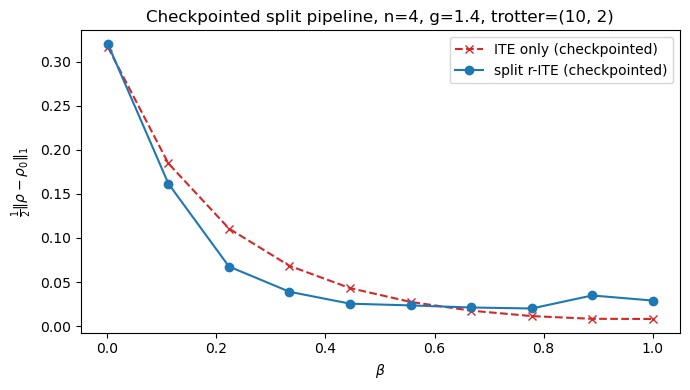

diagnostic ITE p-product per beta: ['1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00', '1.000e+00']
mean gadget shots per beta: [64. 64. 64. 64. 64. 64. 64. 64. 64. 64.]


In [9]:
rho_ite, rho_rite, p_ite, meta = run_split_over_betas(
    Hs,
    n,
    betas,
    trotter=trotter,
    rte_samples=rte_samples,
    ite_shot_batch=ite_shot_batch,
    ite_max_shots=ite_max_shots,
    noise_model=make_noise_model(noise),
    batch_size=batch_size,
    checkpointed=True,
)

tr_i = np.array([trdist(rho_ite[i], ground_rho) for i in range(len(betas))])
tr_r = np.array([trdist(rho_rite[i], ground_rho) for i in range(len(betas))])

plt.figure(figsize=(7, 4))
plt.plot(betas, tr_i, '--x', color='tab:red', mfc='none', label='ITE only (checkpointed)')
plt.plot(betas, tr_r, '-o', color='tab:blue', label='split r-ITE (checkpointed)')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\frac{1}{2}\|\rho-\rho_0\|_1$')
plt.title(f'Checkpointed split pipeline, n={n}, g={g}, trotter={trotter}')
plt.legend()
plt.tight_layout()
plt.show()

print('diagnostic ITE p-product per beta:', [f'{x:.3e}' for x in p_ite])
print('mean gadget shots per beta:', np.round([np.mean(x['tries']) if len(x['tries']) else np.inf for x in meta], 1))
